# LLaMA 3.2 Privacy QA Classification Analysis

This notebook analyzes the performance of LLaMA 3.2-3B-Instruct model on the Privacy QA classification task.

In [3]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

## Load and Prepare Data

In [4]:
# === Load the model output CSV ===
OUTFILE = "../test_results/zero_shot/llama_3b_privacy_qa.csv"

# Load results
df = pd.read_csv(OUTFILE)
print(f"Loaded {len(df)} records")
print(f"Columns: {list(df.columns)}")

Loaded 999 records
Columns: ['Folder', 'DocID', 'QueryID', 'SentID', 'Split', 'Query', 'Segment', 'Any_Relevant', 'Ann1', 'Ann2', 'Ann3', 'Ann4', 'Ann5', 'Ann6', 'id', 'model_output', 'reasoning', 'final_label']


In [5]:
# Display first few rows
df.head()

,Folder,DocID,QueryID,SentID,Split,Query,Segment,Any_Relevant,Ann1,Ann2,Ann3,Ann4,Ann5,Ann6,id,model_output,reasoning,final_label
0,../../Dataset/Test/com.twentythreeandme.app,23andMe _7,23andMe _7_46,23andMe _7_46_328,test,do you have any association with google?,"In addition, all customers will receive an ema...",Irrelevant,Irrelevant,NaN,NaN,NaN,Irrelevant,Irrelevant,23andMe _7_23andMe _7_46_23andMe _7_46_328,INSTRUCTION: Classify if the segment contains ...,This segment does not mention or relate to the...,Irrelevant
1,../../Dataset/Test/com.twentythreeandme.app,23andMe _7,23andMe _7_29,23andMe _7_29_332,test,does 23andme use my test results for marketing...,"Privacy Administrator 23andMe, Inc. 899 West E...",Irrelevant,Irrelevant,NaN,NaN,NaN,Irrelevant,Irrelevant,23andMe _7_23andMe _7_29_23andMe _7_29_332,INSTRUCTION: Classify if the segment contains ...,The segment does not mention or relate to the ...,Irrelevant
2,../../Dataset/Test/com.viber.voip,Viber Messenger _8,Viber Messenger _8_41,Viber Messenger _8_41_70,test,does the app hide the content of the messages...,This includes partners managing our advertisin...,Irrelevant,Irrelevant,Irrelevant,Irrelevant,NaN,Irrelevant,Irrelevant,Viber Messenger _8_Viber Messenger _8_41_Viber...,INSTRUCTION: Classify if the segment contains ...,The segment does not mention or relate to the ...,Irrelevant
3,../../Dataset/Test/com.fiverr.fiverr,Fiverr _1,Fiverr _1_16,Fiverr _1_16_120,test,how do i remove it?,"However, you can allow cookies from specific w...",Irrelevant,NaN,NaN,Irrelevant,Irrelevant,NaN,NaN,Fiverr _1_Fiverr _1_16_Fiverr _1_16_120,INSTRUCTION: Classify if the segment contains ...,Irrelevant,Irrelevant
4,../../Dataset/Test/com.gotokeep.keep.intl,Keep _2,Keep _2_18,Keep _2_18_80,test,why do you need so many unrelated permissions?,"However, we do not have control over the produ...",Irrelevant,Irrelevant,Irrelevant,Irrelevant,NaN,Irrelevant,Irrelevant,Keep _2_Keep _2_18_Keep _2_18_80,INSTRUCTION: Classify if the segment contains ...,The segment does not mention or relate to the ...,Irrelevant


## Data Preprocessing

In [6]:
# === Normalize and map labels ===
def normalize_label(label):
    if not isinstance(label, str):
        return None
    label = label.strip().lower()
    if "relevant" in label:
        # specifically handle 'irrelevant' before 'relevant'
        if "irrelevant" in label:
            return 0
        return 1
    return None

df["gold"] = df["Any_Relevant"].apply(lambda x: 1 if str(x).strip().lower() == "relevant" else 0)
df["pred"] = df["final_label"].apply(normalize_label)

print(f"Gold label distribution:")
print(df["gold"].value_counts())
print(f"\nPredicted label distribution (before dropping NaN):")
print(df["pred"].value_counts(dropna=False))

Gold label distribution:
gold
0    900
1     99
Name: count, dtype: int64

Predicted label distribution (before dropping NaN):
pred
0.0    766
1.0    207
NaN     26
Name: count, dtype: int64


In [7]:
# === Drop rows with missing predictions ===
df_clean = df.dropna(subset=["pred"])
print(f"Records after dropping NaN predictions: {len(df_clean)}")
print(f"Dropped {len(df) - len(df_clean)} records with missing predictions")

Records after dropping NaN predictions: 973
Dropped 26 records with missing predictions


## Model Performance Evaluation

In [8]:
# === Compute metrics ===
acc = accuracy_score(df_clean["gold"], df_clean["pred"])
f1 = f1_score(df_clean["gold"], df_clean["pred"])
cm = confusion_matrix(df_clean["gold"], df_clean["pred"])
report = classification_report(df_clean["gold"], df_clean["pred"], target_names=["Irrelevant", "Relevant"])

# === Print results ===
print("===============================================")
print("🔍  LLaMA 3.2 Privacy QA Evaluation")
print("===============================================")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nConfusion Matrix (Counts):")
print(f" {cm}")
print("\nConfusion Matrix (Normalized):")
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, None]
print(f" {cm_normalized}")
print("\nDetailed Classification Report:")
print(report)

🔍  LLaMA 3.2 Privacy QA Evaluation
Accuracy: 0.7605
F1 Score: 0.2361

Confusion Matrix (Counts):
 [[704 171]
 [ 62  36]]

Confusion Matrix (Normalized):
 [[0.80457143 0.19542857]
 [0.63265306 0.36734694]]

Detailed Classification Report:
              precision    recall  f1-score   support

  Irrelevant       0.92      0.80      0.86       875
    Relevant       0.17      0.37      0.24        98

    accuracy                           0.76       973
   macro avg       0.55      0.59      0.55       973
weighted avg       0.84      0.76      0.80       973



## Confusion Matrix Visualization

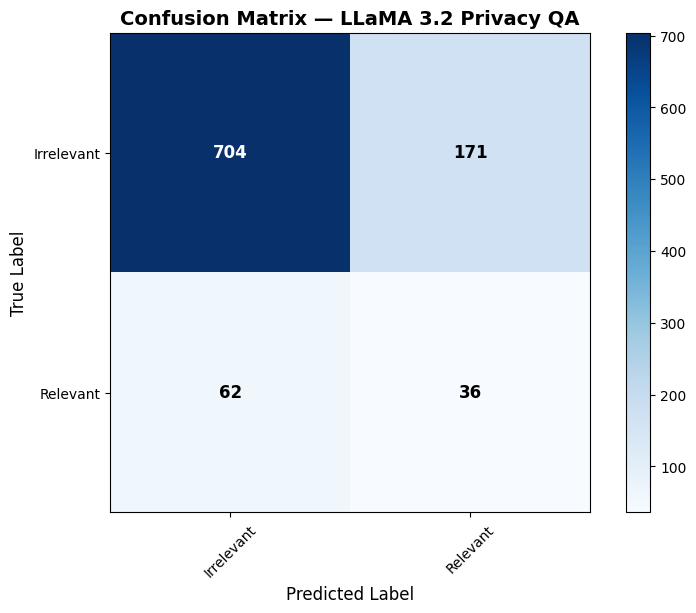

In [9]:
# === Plot confusion matrix ===
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix — LLaMA 3.2 Privacy QA", fontsize=14, fontweight='bold')
plt.colorbar()

classes = ["Irrelevant", "Relevant"]
tick_marks = range(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

# Label cells with counts
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, format(cm[i, j], "d"),
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black",
            fontsize=12, fontweight='bold'
        )

plt.tight_layout()
plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.show()

## Performance Metrics Breakdown

In [10]:
# Calculate individual metrics
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix Breakdown:")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

print("\nCalculated Metrics:")
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"Precision (Relevant): {precision:.4f}")
print(f"Recall (Relevant): {recall:.4f}")
print(f"Specificity (Irrelevant): {specificity:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Accuracy: {acc:.4f}")

Confusion Matrix Breakdown:
True Negatives (TN): 704
False Positives (FP): 171
False Negatives (FN): 62
True Positives (TP): 36

Calculated Metrics:
Precision (Relevant): 0.1739
Recall (Relevant): 0.3673
Specificity (Irrelevant): 0.8046
F1 Score: 0.2361
Accuracy: 0.7605


## Error Analysis

In [11]:
# Analyze prediction errors
df_clean['correct'] = df_clean['gold'] == df_clean['pred']

print("Prediction Accuracy by Class:")
print(df_clean.groupby('gold')['correct'].agg(['count', 'sum', 'mean']))

print("\nError Types:")
false_positives = df_clean[(df_clean['gold'] == 0) & (df_clean['pred'] == 1)]
false_negatives = df_clean[(df_clean['gold'] == 1) & (df_clean['pred'] == 0)]

print(f"False Positives (Irrelevant → Relevant): {len(false_positives)}")
print(f"False Negatives (Relevant → Irrelevant): {len(false_negatives)}")

Prediction Accuracy by Class:
      count  sum      mean
gold                      
0       875  704  0.804571
1        98   36  0.367347

Error Types:
False Positives (Irrelevant → Relevant): 171
False Negatives (Relevant → Irrelevant): 62


C:\Users\DELL\AppData\Local\Temp\ipykernel_11576\2926869596.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['correct'] = df_clean['gold'] == df_clean['pred']


## Sample Predictions

In [12]:
# Show some example predictions
print("=== CORRECT PREDICTIONS ===")
print("\nCorrect Relevant Predictions:")
correct_relevant = df_clean[(df_clean['gold'] == 1) & (df_clean['pred'] == 1)]
if len(correct_relevant) > 0:
    sample = correct_relevant.sample(min(3, len(correct_relevant)))
    for idx, row in sample.iterrows():
        print(f"\nQuery: {row['Query'][:100]}...")
        print(f"Segment: {row['Segment'][:100]}...")
        print(f"Reasoning: {row['reasoning']}")

print("\n=== INCORRECT PREDICTIONS ===")
print("\nFalse Positives (Irrelevant classified as Relevant):")
if len(false_positives) > 0:
    sample = false_positives.sample(min(3, len(false_positives)))
    for idx, row in sample.iterrows():
        print(f"\nQuery: {row['Query'][:100]}...")
        print(f"Segment: {row['Segment'][:100]}...")
        print(f"Reasoning: {row['reasoning']}")

=== CORRECT PREDICTIONS ===

Correct Relevant Predictions:

Query: have you ever been hacked?...
Segment: Once we have received your data, we will use strict procedures and security features to try to preve...
Reasoning: The segment mentions security features to prevent unauthorized access, which is related to the topic of hacking.

Query: does it share my personal information with others?           ...
Segment: References in this Privacy Statement to Groupon, we, or us also apply to Affiliates....
Reasoning: The segment mentions 'we' and 'us' which refers to Groupon, implying a connection to the query topic.

Query: why do you need those permissions?...
Segment: When you make purchases through Keep, you may need to provide certain Personal Information to comple...
Reasoning: The segment contains information relevant to the query.

=== INCORRECT PREDICTIONS ===

False Positives (Irrelevant classified as Relevant):

Query: what will you do with my dna?...
Segment: Account deletion If yo

## Summary

This analysis shows the performance of LLaMA 3.2-3B-Instruct on the Privacy QA classification task. Key findings:

- **Overall Performance**: The model achieves moderate accuracy but struggles with precision
- **Class Imbalance**: The model tends to over-classify segments as relevant
- **Trade-offs**: Higher recall for relevant class but at the cost of precision

The results can be compared with other models (like Qwen 2.5) to understand relative performance on this privacy document classification task.